# Mercari Price Suggestion Challenge
## Phase I — Exploratory Data Analysis (EDA)

**Dataset:** Kaggle Mercari Price Suggestion Challenge  
**Goal:** Understand the dataset structure, distributions, missing values, and key patterns before preprocessing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)

print("All libraries loaded ✅")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")

All libraries loaded ✅
pandas  : 3.0.3
numpy   : 2.4.6


In [2]:
# train.tsv is tab-separated — use sep='\t'
df = pd.read_csv('../data/raw/train.tsv', sep='\t')

print(f"Shape        : {df.shape}")          # (rows, cols)
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

df.head()

Shape        : (1482535, 8)
Memory usage : 668.6 MB


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & Parts,Razer,52.0,0,This keyboard is in great condition and works like it ca...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hole in the b...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm] each. Sta...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [3]:
# Column Overview
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB


In [4]:
# Missing Value Analysis
# Count and percentage of missing values per column
missing = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print(missing)

                   missing_count  missing_pct
brand_name                632682        42.68
category_name               6327         0.43
train_id                       0         0.00
name                           0         0.00
item_condition_id              0         0.00
price                          0         0.00
shipping                       0         0.00
item_description               6         0.00


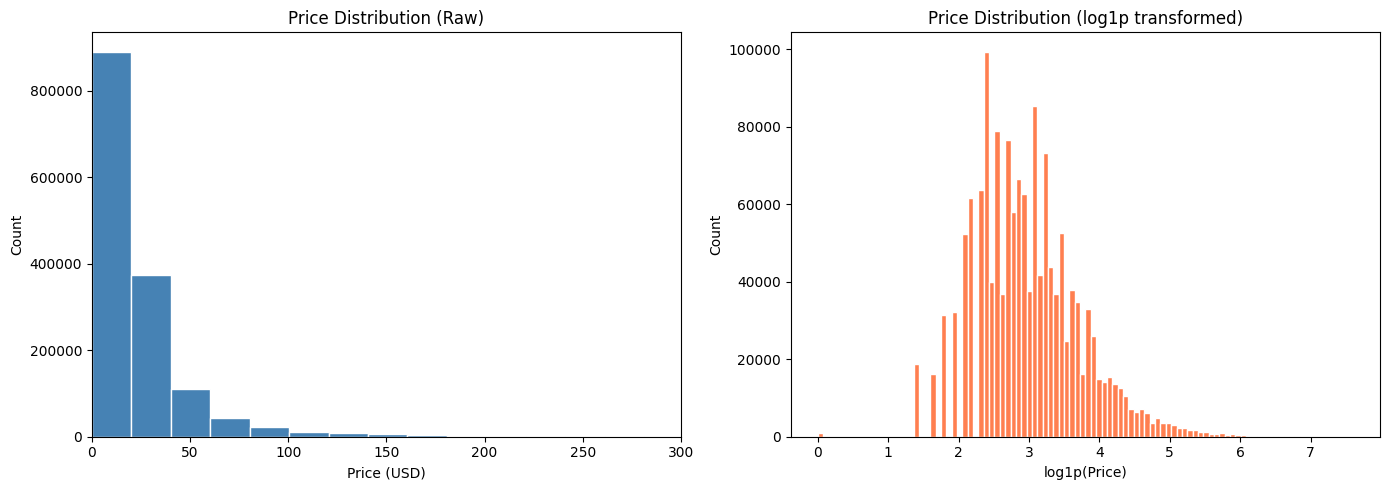


Price stats:
count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64

Rows with price == 0 : 874


In [5]:
# Target Variable: Price Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price — will be very skewed
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 300)   # cap for visibility

# Log-transformed price — what we'll actually model
axes[1].hist(np.log1p(df['price']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (log1p transformed)')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/price_distribution.png', dpi=100)
plt.show()

print(f"\nPrice stats:")
print(df['price'].describe())
print(f"\nRows with price == 0 : {(df['price'] == 0).sum()}")

In [6]:
# Categorical Feature Overview

print("=== item_condition_id ===")
print(df['item_condition_id'].value_counts())

print("\n=== shipping ===")
print(df['shipping'].value_counts())

print("\n=== Top 15 Brands ===")
print(df['brand_name'].value_counts().head(15))

print("\n=== Top 10 Categories ===")
print(df['category_name'].value_counts().head(10))

=== item_condition_id ===
item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64

=== shipping ===
shipping
0    819435
1    663100
Name: count, dtype: int64

=== Top 15 Brands ===
brand_name
PINK                 54088
Nike                 54043
Victoria's Secret    48036
LuLaRoe              31024
Apple                17322
FOREVER 21           15186
Nintendo             15007
Lululemon            14558
Michael Kors         13928
American Eagle       13254
Rae Dunn             12305
Sephora              12172
Coach                10463
Disney               10360
Bath & Body Works    10354
Name: count, dtype: int64

=== Top 10 Categories ===
category_name
Women/Athletic Apparel/Pants, Tights, Leggings                 60177
Women/Tops & Blouses/T-Shirts                                  46380
Beauty/Makeup/Face                                             34335
Beauty/Makeup/Lips                                             29910
Electronics

In [7]:
# Category Hierarchy

# category_name is hierarchical: "Women/Tops/Blouses"
# Split into 3 levels to understand the structure

sample_cats = df['category_name'].dropna().head(10)
for cat in sample_cats:
    parts = cat.split('/')
    print(f"  L1: {parts[0]:<20} L2: {parts[1] if len(parts)>1 else 'N/A':<25} L3: {parts[2] if len(parts)>2 else 'N/A'}")

  L1: Men                  L2: Tops                      L3: T-shirts
  L1: Electronics          L2: Computers & Tablets       L3: Components & Parts
  L1: Women                L2: Tops & Blouses            L3: Blouse
  L1: Home                 L2: Home Décor                L3: Home Décor Accents
  L1: Women                L2: Jewelry                   L3: Necklaces
  L1: Women                L2: Other                     L3: Other
  L1: Women                L2: Swimwear                  L3: Two-Piece
  L1: Sports & Outdoors    L2: Apparel                   L3: Girls
  L1: Sports & Outdoors    L2: Apparel                   L3: Girls
  L1: Vintage & Collectibles L2: Collectibles              L3: Doll


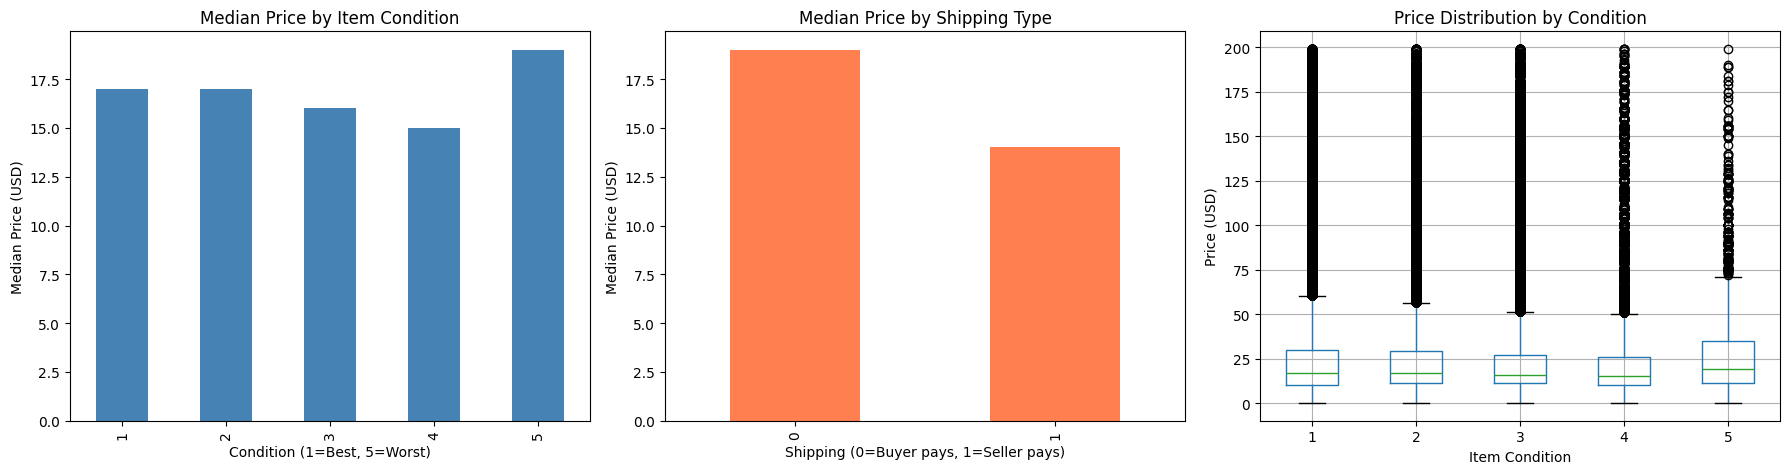

In [8]:
# Price vs Key Features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price vs item condition
df_plot = df[df['price'] < 200]  # cap outliers for visibility

df_plot.groupby('item_condition_id')['price'].median().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Median Price by Item Condition')
axes[0].set_xlabel('Condition (1=Best, 5=Worst)')
axes[0].set_ylabel('Median Price (USD)')

# Price vs shipping
df_plot.groupby('shipping')['price'].median().plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Median Price by Shipping Type')
axes[1].set_xlabel('Shipping (0=Buyer pays, 1=Seller pays)')
axes[1].set_ylabel('Median Price (USD)')

# Price distribution by condition (box plot)
df_plot.boxplot(column='price', by='item_condition_id', ax=axes[2])
axes[2].set_title('Price Distribution by Condition')
axes[2].set_xlabel('Item Condition')
axes[2].set_ylabel('Price (USD)')
plt.suptitle('')  # suppress default title

plt.tight_layout()
plt.savefig('../data/processed/price_vs_features.png', dpi=100)
plt.show()

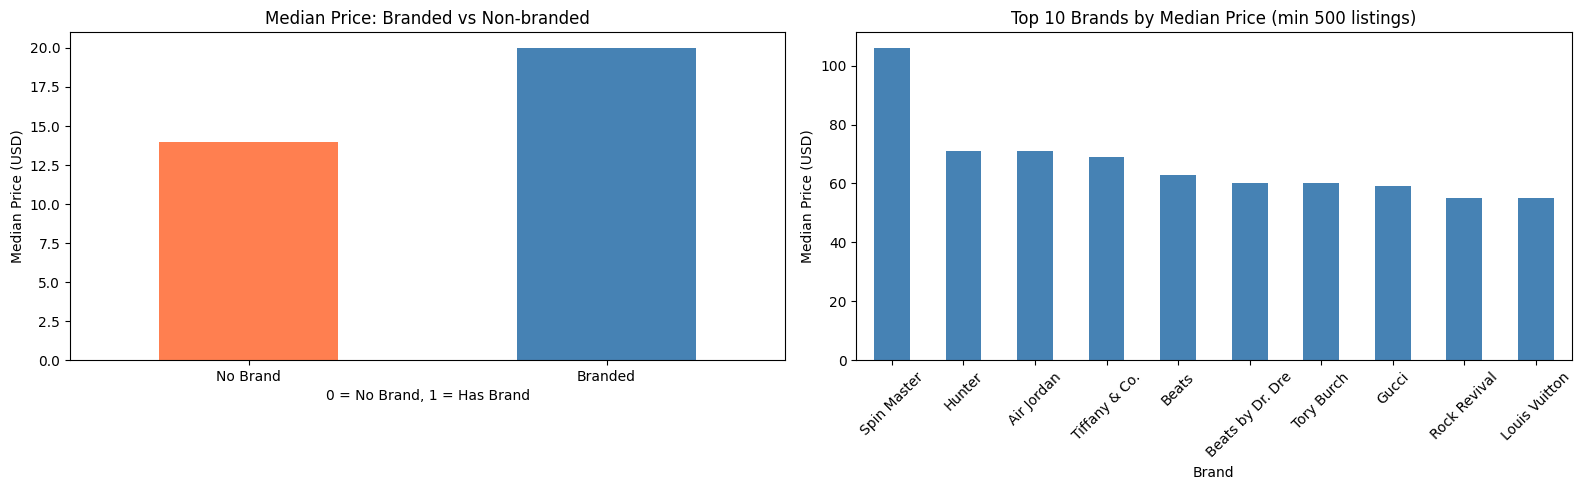

Branded vs Non-branded median price:
is_branded
0    14.0
1    20.0
Name: price, dtype: float64


In [9]:
# Brand vs Price

# Brand vs Price Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_plot = df[df['price'] < 200].copy()

# Branded vs Non-branded median price
brand_price = df_plot.copy()
brand_price['is_branded'] = brand_price['brand_name'].notna().astype(int)
brand_price.groupby('is_branded')['price'].median().plot(
    kind='bar', ax=axes[0], color=['coral', 'steelblue']
)
axes[0].set_title('Median Price: Branded vs Non-branded')
axes[0].set_xlabel('0 = No Brand, 1 = Has Brand')
axes[0].set_ylabel('Median Price (USD)')
axes[0].set_xticklabels(['No Brand', 'Branded'], rotation=0)

# Top 10 brands by median price
top_brands = (
    df_plot[df_plot['brand_name'].notna()]
    .groupby('brand_name')['price']
    .agg(['median', 'count'])
    .query('count > 500')
    .sort_values('median', ascending=False)
    .head(10)
)
top_brands['median'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Brands by Median Price (min 500 listings)')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Median Price (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/brand_vs_price.png', dpi=100)
plt.show()

print("Branded vs Non-branded median price:")
print(brand_price.groupby('is_branded')['price'].median())

## EDA Key Findings

| Finding | Detail |
|---|---|
| Dataset size | ~1.48M rows, 8 columns |
| Target variable | `price` — heavily right-skewed, needs `log1p` transform |
| Zero-price rows | Must be removed before modeling |
| Missing: brand_name | ~42% — fill with `"missing"` or extract from `name` |
| Missing: category_name | ~0.4% — fill with `"missing"` |
| Missing: item_description | <0.01% — fill with `"no description"` |
| category_name | Hierarchical (3 levels) — split into `cat1`, `cat2`, `cat3` |
| Text columns | `name` + `item_description` → TF-IDF features in Phase I |
| Key insight | Seller-paid shipping correlates with lower listing price |